In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
import json

from CMR_IA.fitting import make_boundary, get_wmse

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVERES = False
SAVERES2 = True

## Load Stimuli and Semantic Matrix

In [48]:
# Load study and test data
df_study = pd.read_parquet("data/simu8_study.parquet")
df_test = pd.read_parquet("data/simu8_test.parquet")

In [49]:
# Inspect study data
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session,group
0,12,24,Face12,Joe,0,0,0,1
1,2,29,Face2,Mark,1,0,0,1
2,6,27,Face6,Dan,2,0,0,1
3,13,18,Face13,John,3,0,0,1
4,11,31,Face11,George,4,0,0,1
...,...,...,...,...,...,...,...,...
239995,12,18,Face12,John,11,0,9999,2
239996,7,29,Face7,Mark,12,0,9999,2
239997,10,26,Face10,Chris,13,0,9999,2
239998,1,23,Face1,Charles,14,0,9999,2


In [50]:
# Inspect test data
df_test

,test_itemno1,test_itemno2,test_item1,test_item2,correct_ans,study_pos,test,list,session,group
0,1,-1,Face1,None,30,6,1,0,0,1
1,2,-1,Face2,None,29,1,1,0,0,1
2,6,-1,Face6,None,27,2,1,0,0,1
3,14,-1,Face14,None,22,7,1,0,0,1
4,13,-1,Face13,None,18,3,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
399995,12,-1,Face12,None,18,11,2,0,9999,2
399996,3,-1,Face3,None,25,15,2,0,9999,2
399997,10,-1,Face10,None,26,13,2,0,9999,2
399998,16,-1,Face16,None,19,0,2,0,9999,2


In [51]:
# Load semantic matrix
sem_mat = np.load("data/simu8_smat.npy")

# Group 2

In [52]:
df_study_g2 = df_study.query("group == 2").copy()
df_test_g2 = df_test.query("group == 2").copy()
df_study_g2 = df_study_g2.query("session < 2000").copy()
df_test_g2 = df_test_g2.query("session < 2000").copy()

## Run CMR-IA

In [53]:
# Define parameters and load PSO results
params_path = "/Users/bei/BeiWorld/Research/2022CMRIA/CMR_IA/Analysis/simuS1_recog_cr/data/simuS1_params.json"
params = cmr.load_params("S1", params_path=params_path, fixed_params={"learn_while_retrieving": True, "nitems_in_accumulator": 32, "ban_recall": np.arange(1, 17)})
params.update(beta_cue=0.5, s_fc=0.5)
params

{'beta_enc': 0.613711,
 'beta_rec': 0.611305,
 'beta_cue': 0.5,
 'beta_rec_post': 0.999995,
 'beta_distract': 0.408592,
 'beta_enc_inpair': None,
 's_fc': 0.5,
 's_cf': 0.217875,
 'phi_s': 2.424486,
 'phi_d': 3.04304,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 2.817642,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1.165438,
 'c_thresh_assoc': 1.024938,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': 0.428492,
 'eta': 0.147015,
 'omega': 8.622752,
 'alpha': 0.533889,
 'lamb': 0.023294,
 'c_thresh': 0.18099,
 'ban_recall': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 32,
 'max_recalls': 50,
 'learn_while_retrieving': True,
 'gamma_fc': 0.445102,
 'gamma_cf': 0.701424}

In [54]:
# Run model or load saved results
if SAVERES2:
    df_simu_g2, f_in, f_dif = cmr.run_success_multi_sess(params, df_study_g2, df_test_g2, sem_mat, mode="Recog-CR", design="S1G3")
    df_simu_g2["test"] = df_test_g2["test"]
    df_simu_g2 = df_simu_g2.merge(df_test_g2, on=["session", "list", "test", "test_itemno1", "test_itemno2"])
#     df_simu_g2.to_parquet("data/simu8_result_g2.parquet")
# else:
#     df_simu_g2 = pd.read_parquet("data/simu8_result_g2.parquet")
df_simu_g2

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:10<00:00, 195.56it/s]


CMR Time: 10.321677207946777


,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group
0,0,0,15,30,0,0,0.536687,0.542679,1,Face15,Mike,1,-1,2
1,0,0,4,17,0,0,0.490983,0.549630,1,Face4,Jim,1,-1,2
2,0,0,10,28,0,0,0.426189,0.505999,1,Face10,Paul,0,-1,2
3,0,0,2,23,1,0,0.534534,0.440950,1,Face2,Charles,1,-1,2
4,0,0,1,27,0,0,0.409590,0.541477,1,Face1,Dan,0,-1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,1999,0,16,-1,20,910,0.457938,0.180990,2,Face16,None,22,15,2
63996,1999,0,9,-1,24,800,0.627772,0.180990,2,Face9,None,26,14,2
63997,1999,0,4,-1,32,700,0.751280,0.180990,2,Face4,None,17,12,2
63998,1999,0,12,-1,29,800,0.705757,0.180990,2,Face12,None,18,3,2


## Analysis

In [55]:
# Split recognition and cued recall responses
df_recog = df_simu_g2.query("test == 1").copy()
df_cr = df_simu_g2.query("test == 2").copy()

In [56]:
# Get name-face pair dict for each session
sess_name_face = {}
for sess in df_study_g2.session.unique():
    sess_name_face[sess] = df_study_g2.query(f"session == {sess}")[["study_itemno1", "study_itemno2"]].set_index("study_itemno2").to_dict()["study_itemno1"]

### Neighborhood Effect

In [57]:
# Load face distance matrix and compute neighbour counts (all 16 faces studied every session)
face_distance = np.load("data/simu8_distance.npy")
thresh = 3.0
neighbour_count = ((face_distance < thresh) & (face_distance > 0)).sum(axis=1)

# Density group of each recognition probe face
df_recog["neighbour"] = df_recog["test_itemno1"].apply(lambda f: neighbour_count[f - 1])
df_recog["density"] = pd.cut(df_recog["neighbour"], [4, 6, 8, 10], labels=["low", "medium", "high"])
df_recog["yes"] = (df_recog["s_resp"] == 1).astype(int)
df_recog

,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group,neighbour,density,yes
0,0,0,15,30,0,0,0.536687,0.542679,1,Face15,Mike,1,-1,2,10,high,0
1,0,0,4,17,0,0,0.490983,0.549630,1,Face4,Jim,1,-1,2,6,low,0
2,0,0,10,28,0,0,0.426189,0.505999,1,Face10,Paul,0,-1,2,10,high,0
3,0,0,2,23,1,0,0.534534,0.440950,1,Face2,Charles,1,-1,2,8,medium,1
4,0,0,1,27,0,0,0.409590,0.541477,1,Face1,Dan,0,-1,2,10,high,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63979,1999,0,2,24,1,0,0.439743,0.403503,1,Face2,Joe,0,-1,2,8,medium,1
63980,1999,0,6,29,1,0,0.522279,0.447888,1,Face6,Mark,1,-1,2,7,medium,1
63981,1999,0,12,18,0,0,0.526627,0.530081,1,Face12,John,1,-1,2,8,medium,0
63982,1999,0,16,22,0,0,0.514147,0.539181,1,Face16,Rich,1,-1,2,9,high,0


In [58]:
# Hit rate and false alarm rate by density
df_hr = df_recog.query("correct_ans == 1").groupby("density", observed=True).yes.mean().reset_index(name="HR")
df_far = df_recog.query("correct_ans == 0").groupby("density", observed=True).yes.mean().reset_index(name="FAR")
df_hr, df_far

(  density        HR
 0     low  0.625455
 1  medium  0.633130
 2    high  0.624366,
   density       FAR
 0     low  0.263866
 1  medium  0.264871
 2    high  0.256495)

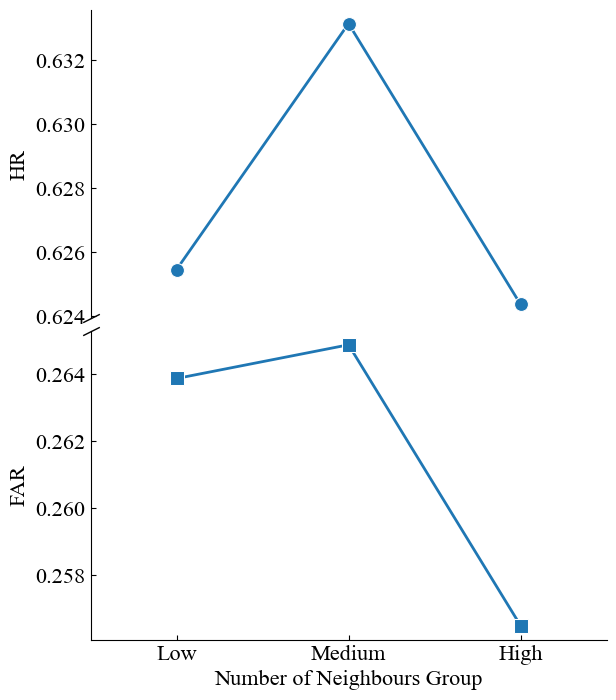

In [59]:
# Plot hit rate and false alarm rate by density (stacked, broken y-axis)
xpos = np.arange(3)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 7))
fig.subplots_adjust(left=0.12, right=0.98, bottom=0.08, top=0.98, hspace=0.04)

sns.lineplot(x=xpos, y=df_hr["HR"].to_numpy(), ax=ax1, marker="o", color="C0", markersize=10, linewidth=2)
sns.lineplot(x=xpos, y=df_far["FAR"].to_numpy(), ax=ax2, marker="s", color="C0", markersize=10, linewidth=2)

# ax1.set_ylim(0.73, 0.90)
# ax2.set_ylim(0.20, 0.37)
for ax in (ax1, ax2):
    ax.tick_params(axis="y", direction="in")
    ax.tick_params(axis="x", direction="in")
    ax.spines.right.set_visible(False)
ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.tick_params(axis="x", which="both", bottom=False)

# Slanted break marks between the two panels
d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

ax2.set_xticks(xpos)
ax2.set_xticklabels(["Low", "Medium", "High"])
ax2.set_xlim(-0.5, 2.5)
ax1.set_ylabel("HR")
ax2.set_ylabel("FAR")
ax2.set_xlabel("Number of Neighbours Group")

if SAVEFIG:
    ax1.set_ylabel(None)
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    plt.savefig("figures/simu8_g2_hrfar-neighbor.pdf")
plt.show()

## Mechanism Check: Neighbourhood Effect on Recognition

Human data (exp3 ground truth) show a distinctiveness effect: in denser neighbourhoods HR
falls and FAR rises. The puzzle is that the model instead gives a tiny drop in *both* HR and
FAR. The checks below show the actual reason: in this model the recognition evidence carries
almost no neighbourhood information, so the small wiggles are essentially noise, not a real
mechanism.

Recognition evidence is `csim = dot(c_old, c_in)` between unit-normalized context vectors
(`_core.pyx:746`). The only path from neighbourhood to recognition is `s_fc * sem_mat` in
`M_FC` (`_core.pyx:287-292`); the `sem_mean` attention/criterion paths (`_core.pyx:364,373`)
are off because `psi_s = 0` and `c_s = 0`. That path is weak, and the diagnostic signal for a
face-name probe is the episodic face<->name co-occurrence, which is independent of how many
neighbours the face has (names carry no semantic neighbours).

In [60]:
# csim, threshold, and yes-rate by neighbour count -- the recognition evidence is flat
df_recog["yes"] = (df_recog["s_resp"] == 1).astype(int)
for ca, lab in [(1, "target"), (0, "lure")]:
    sub = df_recog.query("correct_ans == @ca")
    g = sub.groupby("neighbour").agg(csim=("csim", "mean"), thresh=("thresh", "mean"), yes=("yes", "mean"), n=("yes", "size"))
    print(f"--- {lab} ---")
    print(g.round(4).to_string())
    print(f"corr(neighbour, csim)={np.corrcoef(sub.neighbour, sub.csim)[0, 1]:+.4f}  " f"corr(neighbour, yes)={np.corrcoef(sub.neighbour, sub.yes)[0, 1]:+.4f}\n")

--- target ---
             csim  thresh     yes     n
neighbour                              
5          0.5121  0.4781  0.6279  2013
6          0.5123  0.4774  0.6206  1012
7          0.5097  0.4768  0.6336  1987
8          0.5109  0.4765  0.6329  5070
9          0.5105  0.4784  0.6316  2006
10         0.5102  0.4798  0.6207  3912
corr(neighbour, csim)=-0.0109  corr(neighbour, yes)=-0.0037

--- lure ---
             csim  thresh     yes     n
neighbour                              
5          0.4193  0.4846  0.2572  1987
6          0.4225  0.4818  0.2773   988
7          0.4198  0.4829  0.2653  2013
8          0.4213  0.4832  0.2647  4930
9          0.4220  0.4847  0.2598  1994
10         0.4225  0.4862  0.2549  4088
corr(neighbour, csim)=+0.0137  corr(neighbour, yes)=-0.0062



In [61]:
# Model vs. human HR/FAR by density: the model barely moves and gets the FAR direction wrong
comp = pd.DataFrame(
    {
        "density": ["low", "medium", "high"],
        "HR_model": df_hr["HR"].to_numpy(),
        "FAR_model": df_far["FAR"].to_numpy(),
    }
)
comp

,density,HR_model,FAR_model
0,low,0.625455,0.263866
1,medium,0.633130,0.264871
2,high,0.624366,0.256495


In [62]:
# Why the evidence is flat: re-encode a few sessions and measure, per face, the raw norm of the
# cued context M_FC.f and its normalized self-component. Both are essentially invariant across
# faces (range < ~1.5%), so neighbour count cannot move csim.
from CMR_IA._core import CMR

n_demo_sess = 50
list_num = len(np.unique(df_study_g2.list))
raw_norm_acc = np.zeros(16)
self_frac_acc = np.zeros(16)

# Loop over a subset of sessions, replicating only pretrial + encoding of run_success_single_sess
for sess in np.unique(df_study_g2.session)[:n_demo_sess]:
    pres_mat = np.reshape(df_study_g2.loc[df_study_g2.session == sess, ["study_itemno1", "study_itemno2"]].to_numpy(), (list_num, -1, 2))
    cue_mat = np.reshape(df_test_g2.loc[df_test_g2.session == sess, ["test_itemno1", "test_itemno2"]].to_numpy(), (list_num, -1, 2))
    m = CMR(params, pres_mat, sem_mat, cue_mat=cue_mat, mode="Recog-CR", design="S1G3", seed=int(sess))

    # Pre-trial context shift (beta = 1 on the first trial)
    m.phase = "pretrial"
    m.beta = 1.0
    m.beta_source = 1.0
    m.present_item(m.distractor_idx, None, update_context=True, update_weights=False)
    m.distractor_idx += 1

    # Encode the 16 face-name pairs, learning M_FC exactly as during study
    m.phase = "encoding"
    for m.serial_position in range(m.pres_indexes.shape[1]):
        m.beta = params["beta_enc"]
        m.beta_source = 0
        m.present_item(m.pres_indexes[0, m.serial_position], None, update_context=True, update_weights=True, use_new_context=params["use_new_context"])

    # Per face: raw norm of the temporal cue context and the normalized self-component
    M_FC = np.asarray(m.M_FC)
    for f in range(1, 17):
        idx = int(np.searchsorted(m.all_nos_unique, f))
        v = M_FC[: m.ntemporal, idx]
        raw_norm = np.sqrt(np.sum(v**2))
        raw_norm_acc[f - 1] += raw_norm
        self_frac_acc[f - 1] += v[idx] / raw_norm

# Assemble per-face table; neighbour (euclidean distance < 3) barely relates to the cue representation
face_target_csim = df_recog.query("correct_ans == 1").groupby("test_itemno1").csim.mean()
sem_face = sem_mat[:16, :16].copy()
np.fill_diagonal(sem_face, 0)
df_mech = pd.DataFrame(
    {
        "face": np.arange(1, 17),
        "neighbour": neighbour_count,
        "sum_cos": sem_face.sum(axis=1),  # linear similarity sum (what neighbour count tracks, r~0.6)
        "sum_cos2": (sem_face**2).sum(axis=1),  # quadratic sum (what the cue norm sees, r~0)
        "raw_norm": raw_norm_acc / n_demo_sess,  # ||M_FC . f|| before normalization
        "self_frac": self_frac_acc / n_demo_sess,  # diagnostic self-component after unit-normalization
    }
)
df_mech["target_csim"] = df_mech["face"].map(face_target_csim)
print(f"raw_norm spread  = {df_mech.raw_norm.min():.4f} .. {df_mech.raw_norm.max():.4f}")
print(f"self_frac spread = {df_mech.self_frac.min():.4f} .. {df_mech.self_frac.max():.4f}")
print(f"corr(neighbour, sum_cos)   = {np.corrcoef(df_mech.neighbour, df_mech.sum_cos)[0, 1]:+.3f}")
print(f"corr(neighbour, sum_cos2)  = {np.corrcoef(df_mech.neighbour, df_mech.sum_cos2)[0, 1]:+.3f}")
print(f"corr(neighbour, raw_norm)  = {np.corrcoef(df_mech.neighbour, df_mech.raw_norm)[0, 1]:+.3f}")
print(f"corr(neighbour, csim)      = {np.corrcoef(df_mech.neighbour, df_mech.target_csim)[0, 1]:+.3f}")
df_mech.sort_values("neighbour")

raw_norm spread  = 1.1644 .. 1.1827
self_frac spread = 0.6339 .. 0.6448
corr(neighbour, sum_cos)   = +0.605
corr(neighbour, sum_cos2)  = +0.034
corr(neighbour, raw_norm)  = +0.108
corr(neighbour, csim)      = -0.343


,face,neighbour,sum_cos,sum_cos2,raw_norm,self_frac,target_csim
7,8,5,6.850994,3.910672,1.165578,0.644806,0.511610
8,9,5,6.973224,4.046257,1.167502,0.641688,0.512607
3,4,6,6.906934,4.197492,1.173482,0.636128,0.512299
5,6,7,6.889813,4.225743,1.168319,0.638041,0.509325
10,11,7,7.030715,4.289398,1.182658,0.633859,0.510043
1,2,8,6.953563,4.132619,1.173139,0.637611,0.510482
4,5,8,7.098949,4.000994,1.172279,0.639851,0.510111
11,12,8,7.072018,3.909825,1.172197,0.640826,0.511749
12,13,8,7.008321,4.203287,1.173121,0.637309,0.509327
13,14,8,7.039027,3.870131,1.164368,0.644628,0.512703
